In [1]:
'''!pip install -q -U watermark
!pip install -q yfinance'''

'!pip install -q -U watermark\n!pip install -q yfinance'

In [2]:
import scipy
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

In [3]:
%reload_ext watermark
%watermark -a "Matheus dos Anjos" --iversions

Author: Matheus dos Anjos

numpy     : 2.3.5
matplotlib: 3.10.0
yfinance  : 0.2.66
pandas    : 2.3.3
scipy     : 1.15.3



In [4]:
df = yf.download(['LINK-USD',
                  'SOL-USD',
                  'BTC-USD',
                  'ETH-USD',
                  'DOGE-USD',
                  'LTC-USD',
                  'XRP-USD',
                  'ADA-USD'],
                 start='2021-01-01', end='2025-01-01')

[*********************100%***********************]  8 of 8 completed


In [5]:
df = df['Close']

In [6]:
df.shape

(1461, 8)

In [7]:
df.head(3)

Ticker,ADA-USD,BTC-USD,DOGE-USD,ETH-USD,LINK-USD,LTC-USD,SOL-USD,XRP-USD
Date,,,,,,,,
2021-01-01,0.175350,29374.152344,0.005685,730.367554,11.872555,126.230347,1.842084,0.237444
2021-01-02,0.177423,32127.267578,0.010615,774.534973,12.220137,136.944885,1.799275,0.221655
2021-01-03,0.204995,32782.023438,0.009771,975.507690,13.650172,160.190582,2.161752,0.225848


In [8]:
df.tail(3)

Ticker,ADA-USD,BTC-USD,DOGE-USD,ETH-USD,LINK-USD,LTC-USD,SOL-USD,XRP-USD
Date,,,,,,,,
2024-12-29,0.858640,93530.226562,0.314320,3349.513428,20.938786,98.275055,189.744263,2.093180
2024-12-30,0.860017,92643.210938,0.313514,3356.392578,20.583473,99.309219,191.028046,2.057571
2024-12-31,0.843765,93429.203125,0.315681,3332.531738,20.001366,103.068512,189.264481,2.080128


In [9]:
retornos = df.pct_change().dropna()

In [10]:
retornos.tail(3)

Ticker,ADA-USD,BTC-USD,DOGE-USD,ETH-USD,LINK-USD,LTC-USD,SOL-USD,XRP-USD
Date,,,,,,,,
2024-12-29,-0.032864,-0.017167,-0.029634,-0.014241,-0.046767,-0.022962,-0.027020,-0.040189
2024-12-30,0.001604,-0.009484,-0.002564,0.002054,-0.016969,0.010523,0.006766,-0.017012
2024-12-31,-0.018897,0.008484,0.006912,-0.007109,-0.028280,0.037854,-0.009232,0.010963


In [11]:
media_retornos = retornos.mean()
print(f"A média de retornos é: {media_retornos}")

A média de retornos é: Ticker
ADA-USD     0.002319
BTC-USD     0.001317
DOGE-USD    0.006512
ETH-USD     0.001910
LINK-USD    0.001831
LTC-USD     0.000933
SOL-USD     0.005130
XRP-USD     0.002961
dtype: float64


In [12]:
np.random.seed(42)
# anualização correta para dados diários
trading_days = 252
# número de ativos (dinâmico)
n_assets = retornos.shape[1]

In [13]:
num_portfolios = 10000

In [14]:
all_pesos = np.zeros((num_portfolios, n_assets))

In [15]:
ret_arr = np.zeros(num_portfolios)

In [16]:
vol_arr = np.zeros(num_portfolios)

In [17]:
sharpe_arr = np.zeros(num_portfolios)

In [18]:
cov_matrix = retornos.cov()

In [19]:
for x in range(num_portfolios):

    pesos = np.random.random(n_assets)
    pesos = pesos / np.sum(pesos)

    all_pesos[x, :] = pesos

    # retorno anualizado (a partir da média diária)
    ret_arr[x] = np.sum(media_retornos * pesos) * trading_days

    # volatilidade anualizada
    vol_diaria = np.sqrt(np.dot(pesos.T, np.dot(cov_matrix, pesos)))
    vol_arr[x] = vol_diaria * np.sqrt(trading_days)

    # evitar divisão por zero
    sharpe_arr[x] = ret_arr[x] / vol_arr[x] if vol_arr[x] != 0 else 0.0

In [20]:
all_pesos[:5]

array([[0.09622888, 0.24426269, 0.18806787, 0.15381059, 0.04008516,
        0.04007896, 0.01492316, 0.22254269],
       [0.16203901, 0.19087093, 0.00554884, 0.26145285, 0.22439663,
        0.057239  , 0.04901348, 0.04943927],
       [0.10271424, 0.17716131, 0.14582755, 0.09832092, 0.20656567,
        0.04709407, 0.09863001, 0.12368623],
       [0.13524854, 0.23284562, 0.05921369, 0.15249733, 0.17568182,
        0.01377497, 0.18016874, 0.0505693 ],
       [0.01507695, 0.2199224 , 0.22380372, 0.18736157, 0.07060008,
        0.02263738, 0.15858411, 0.10201377]])

In [21]:
ret_arr[:5]

array([0.73323357, 0.51022661, 0.73164516, 0.68184866, 0.85830542])

In [22]:
vol_arr[:5]

array([0.69202086, 0.62602304, 0.68752852, 0.64111917, 0.73450652])

In [23]:
sharpe_arr[:5]

array([1.05955414, 0.81502849, 1.06416699, 1.06352874, 1.16854704])

In [24]:
print("Sharpe Ratio Máximo:" + str(sharpe_arr.max()))

Sharpe Ratio Máximo:1.3064735121730509


In [25]:
# Relação Sharpe

# Maior que 1 é considerado boa, indicando que o retorno em excesso do investimento compensa adequadamente pelo risco assumido.

# Maior que 2 é considerado muito boa, sugerindo que o investimento oferece um retorno em excesso significativamente maior por cada unidade de risco.

# Maior que 3 é considerado excepcional, indicando um investimento de alta performance em termos de retorno ajustado ao risco.

In [26]:
indice = sharpe_arr.argmax()

In [27]:
contador = 0

In [28]:
for i in ('BTC-USD', 'ETH-USD', 'LTC-USD', 'DOGE-USD', 'XRP-USD', 'ADA-USD', 'SOL-USD', 'LINK-USD'):
    print(f"Peso Atribuído a", i, ":",round(all_pesos[indice,:] [contador], 3))
    contador += 1

Peso Atribuído a BTC-USD : 0.056
Peso Atribuído a ETH-USD : 0.047
Peso Atribuído a LTC-USD : 0.139
Peso Atribuído a DOGE-USD : 0.114
Peso Atribuído a XRP-USD : 0.032
Peso Atribuído a ADA-USD : 0.048
Peso Atribuído a SOL-USD : 0.325
Peso Atribuído a LINK-USD : 0.24


In [29]:
max_sr_ret = ret_arr[indice]
max_sr_vol = vol_arr[indice]

In [30]:
max_sr_ret

np.float64(0.9556285762477702)

In [31]:
max_sr_vol

np.float64(0.7314565257877123)

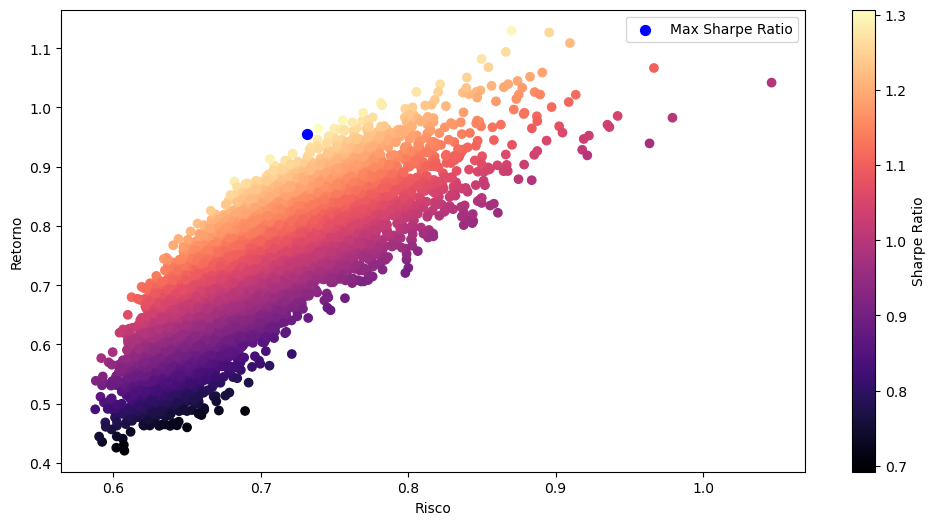

In [32]:
plt.figure(figsize = (12, 6))
plt.scatter(vol_arr, ret_arr, c = sharpe_arr, cmap='magma')
plt.colorbar(label = 'Sharpe Ratio')
plt.xlabel('Risco')
plt.ylabel('Retorno')
plt.scatter(max_sr_vol, max_sr_ret, c = 'blue', s = 50, label = 'Max Sharpe Ratio')
plt.legend()
plt.show()

In [33]:
def get_ret_vol_sr(weights):
    weights = np.array(weights)
    ret = np.sum(media_retornos * weights) * trading_days
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(trading_days)
    sr = ret / vol if vol != 0 else 0.0
    return np.array([ret, vol, sr])

In [34]:
def neg_sharpe(weights):
    return get_ret_vol_sr(weights)[2] * -1

In [35]:
def check_sum(weights):
    return np.sum(weights) - 1

In [36]:
cons = ({'type':'eq', 'fun': check_sum})

In [37]:
limite = (0.0, 1.0)

In [38]:
limites = tuple(limite for asset in range(n_assets))

In [39]:
init_guess = [1.0 / n_assets for i in range(n_assets)]

In [40]:
resultado_otimizacao = minimize(neg_sharpe,
                                 init_guess,
                                 method = 'SLSQP',
                                 bounds = limites,
                                 constraints = cons)

In [41]:
resultado_otimizacao.x

array([0.00000000e+00, 2.27266009e-18, 1.89729128e-01, 0.00000000e+00,
       1.50755652e-17, 1.62063020e-17, 6.47115473e-01, 1.63155399e-01])

In [42]:
get_ret_vol_sr(resultado_otimizacao.x)

array([1.26975779, 0.87732548, 1.44730527])

In [43]:
frontier_y = np.linspace(ret_arr.min(), ret_arr.max(), num = 200)

In [44]:
def retorna_volatilidade(weights):
    return get_ret_vol_sr(weights)[1]

In [45]:
frontier_x = []

In [46]:
for retorno_possivel in frontier_y:
    cons = ({'type':'eq', 'fun': check_sum},
            {'type':'eq', 'fun': lambda w: get_ret_vol_sr(w)[0] - retorno_possivel})
    
    resultado = minimize(retorna_volatilidade,
                          init_guess,
                          method = 'SLSQP',
                          bounds = limites,
                          constraints = cons)

    frontier_x.append(resultado['fun'])

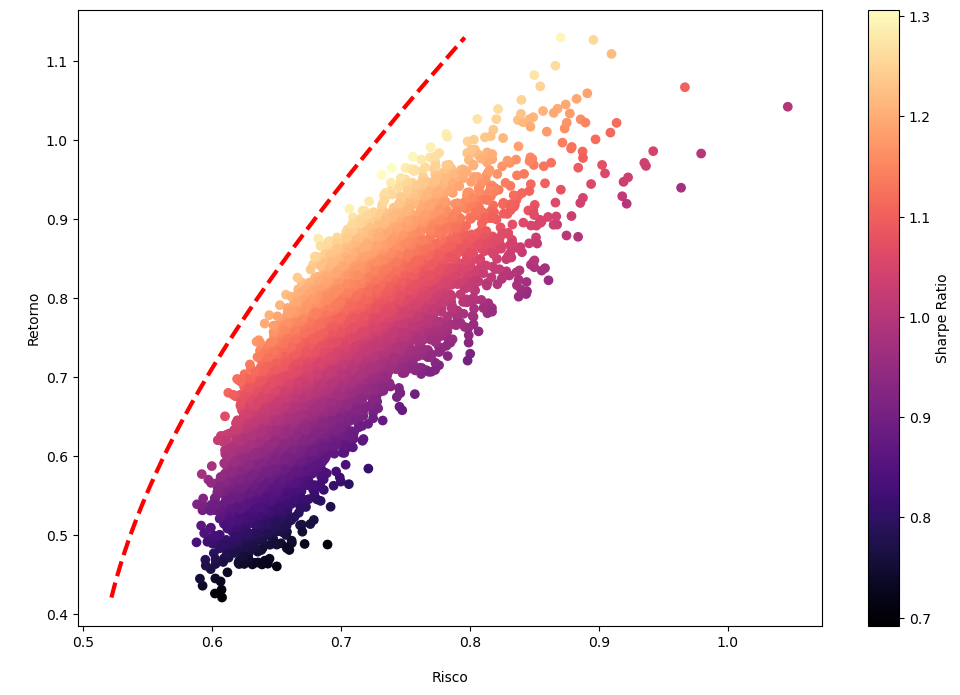

In [47]:
plt.figure(figsize = (12,8))
plt.scatter(vol_arr, ret_arr, c = sharpe_arr, cmap = 'magma')
plt.colorbar(label = 'Sharpe Ratio')
plt.xlabel('\nRisco')
plt.ylabel('\nRetorno')
plt.plot(frontier_x, frontier_y, 'r--', linewidth = 3)
plt.show()

# Parte 2 ------------------------------

In [48]:
num_portfolios = 10000
taxa_livre_risco = 0.015

In [49]:
def portfolio_performance(weights, mean_returns, cov_matrix):
    returns = np.sum(mean_returns * weights) * 62
    std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(62)
    return std, returns

In [50]:
def neg_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate):
    p_var, p_ret = portfolio_performance(weights, mean_returns, cov_matrix)
    sharpe_ratio = (p_ret - risk_free_rate) / p_var
    return -sharpe_ratio

In [52]:
def max_sharpe_rario(mean_returns, cov_matrix, risk_free_rate):
    num_assets = len(mean_returns)
    args = (mean_returns, cov_matrix, risk_free_rate)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bound = (0.0, 1.0)
    bounds = tuple(bound for asset in range(num_assets))
    initial_guess = num_assets * [1. / num_assets,]
    result = minimize(neg_sharpe_ratio, initial_guess, args=args,
                      method='SLSQP', bounds=bounds, constraints=constraints)
    return result

In [53]:
def max_sharpe_ratio(mean_returns, cov_matrix, risk_free_rate):
    num_assets = len(mean_returns)
    args = (mean_returns, cov_matrix, risk_free_rate)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bound = (0.0, 1.0)
    bounds = tuple(bound for asset in range(num_assets))

    result = minimize(neg_sharpe_ratio,
                      initial_guess,
                      args=args,
                      method='SLSQP',
                      bounds=bounds,
                      constraints=constraints)

    return result

In [54]:
def portfolio_volatility(weights, mean_returns, cov_matrix):
    return portfolio_performance(weights, mean_returns, cov_matrix[0])

In [55]:
def min_variance(mena_returns, cov_matrix):
    num_assets = len(media_returns)
    args = (media_returns, cov_matrix)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bound = (0.0, 1.0)
    bounds = tuple(bound for asset in range(num_assets))
    initial_guess = num_assets * [1. / num_assets,]
    result = minimize(portfolio_volatility,
                      initial_guess,
                      args=args,
                      method='SLSQP',
                      bounds=bounds,
                      constraints=constraints)
    return result

In [56]:
def efficient_return(mean_returns, cov_matrix, target):
    num_assers = len(mean_returns)
    args = (mean_returns, cov_matrix)

    def portfolio_return(weights):
        return portfolio_performance(weights, mean_returns, cov_matrix)[1]

        constraints = ({'type':'ep', 'fun': lambda x: portfolio_return(x) - target},
        {'type':'ep', 'fun': lambda x: np.sum(x) - 1})

    bounds = tuple((0,1) for asset in range(num_assets))
    result = minimize(portfolio_volatility,
    num_assets * [1./num_assets,],
    args = args,
    method = 'SLSQP',
    bounds = bounds,
    constraints = constraints)

    return result

In [57]:
def efficient_frontier(mean_returns, cov_matrix, returns_range):
    efficients = []

    for ret in returns_range:
        efficients.append(efficient_return(mean_returns, cov_matrix, ret))
    return efficients

In [ ]:
def print_status(rp, sdp, max_shape_allocation, rp_min, sdp_min, min_vol_allocation, show_portfolio = True):
    if show_portfolio:
        print("-" * 80)
        print("Portfolio com o Maior Sharpe Ratio\n")
        print("Retorno Anualizado: {:.2f}%".format(rp * 100))
        print("Volatilidade Anualizada: {:.2f}%".format(sdp * 100))
        print("Alocação dos Ativos:\n")
        for i, peso in enumerate(max_shape_allocation):
            print("{}: {:.2f}%".format(retornos.columns[i], peso * 100))
        print("-" * 80)
        print("\n")
        print("-" * 80)
        print("Portfolio com a Menor Volatilidade\n")
        print("Retorno Anualizado: {:.2f}%".format(rp_min * 100))
        print("Volatilidade Anualizada: {:.2f}%".format(sdp_min * 100))
        print("Alocação dos Ativos:\n")
        for i, peso in enumerate(min_vol_allocation):
            print("{}: {:.2f}%".format(retornos.columns[i], peso * 100))
        print("-" * 80) 

In [58]:
def plot_stats(results, sdp, rp, sdp_min, frontier_flag = True):
    plt.figure(figsize = (12,8))
    plt.scatter(results[1,:], results[0,:], c = results[2,:], cmap = 'magma')
    plt.colorbar(label = 'Sharpe Ratio')
    plt.xlabel('\nRisco')
    plt.ylabel('\nRetorno')
    plt.scatter(sdp, rp, c = 'blue', s = 50, label = 'Max Sharpe Ratio')
    plt.scatter(sdp_min, rp_min, c = 'green', s = 50, label = 'Min Volatility')
    if frontier_flag:
        plt.plot(frontier_x, frontier_y, 'r--', linewidth = 3)
    plt.legend()
    plt.show()